# Forbes — Face Obfuscation

Official paper: https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/08668.pdf

This notebook combines `adaface.py`, `pattern_utils.py`, `brs.py`, `demo.py`, and `eval.py`. This has been done to enable us run the code in a colab notebook.

## 1. Install Dependencies

In [1]:
!pip install -q opencv-python-headless scipy scikit-image easydict einops timm

## 2. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
ADEFACE_CKPT = '/content/drive/MyDrive/acv_project_weights/adaface_ir101_ms1mv2.ckpt'
OUTPUT_DIR = '/content/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Output dir:', OUTPUT_DIR)

Output dir: /content/output


## 3. AdaFace Model  (`adaface.py`)

In [5]:
from collections import namedtuple
import torch
import torch.nn as nn
from torch.nn import Dropout, MaxPool2d, Sequential, Conv2d, Linear
from torch.nn import BatchNorm1d, BatchNorm2d, ReLU, Sigmoid, Module, PReLU


def initialize_weights(modules):
    for m in modules:
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                m.bias.data.zero_()
        elif isinstance(m, nn.BatchNorm2d):
            m.weight.data.fill_(1)
            m.bias.data.zero_()
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                m.bias.data.zero_()


class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)


class LinearBlock(Module):
    def __init__(self, in_c, out_c, kernel=(1,1), stride=(1,1), padding=(0,0), groups=1):
        super(LinearBlock, self).__init__()
        self.conv = Conv2d(in_c, out_c, kernel, stride, padding, groups=groups, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        return self.bn(self.conv(x))


class GNAP(Module):
    def __init__(self, in_c):
        super(GNAP, self).__init__()
        self.bn1 = BatchNorm2d(in_c, affine=False)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.bn2 = BatchNorm1d(in_c, affine=False)
    def forward(self, x):
        x = self.bn1(x)
        x_norm = torch.norm(x, 2, 1, True)
        weight = torch.mean(x_norm) / x_norm
        x = self.pool(x * weight)
        return self.bn2(x.view(x.shape[0], -1))


class GDC(Module):
    def __init__(self, in_c, embedding_size):
        super(GDC, self).__init__()
        self.conv_6_dw = LinearBlock(in_c, in_c, groups=in_c, kernel=(7,7), stride=(1,1), padding=(0,0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(in_c, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size, affine=False)
    def forward(self, x):
        return self.bn(self.linear(self.conv_6_flatten(self.conv_6_dw(x))))


class SEModule(Module):
    def __init__(self, channels, reduction):
        super(SEModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
        nn.init.xavier_uniform_(self.fc1.weight.data)
        self.relu = ReLU(inplace=True)
        self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
        self.sigmoid = Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.fc2(self.relu(self.fc1(self.avg_pool(x)))))


class BasicBlockIR(Module):
    def __init__(self, in_channel, depth, stride):
        super(BasicBlockIR, self).__init__()
        self.shortcut_layer = (MaxPool2d(1, stride) if in_channel == depth else
            Sequential(Conv2d(in_channel, depth, (1,1), stride, bias=False), BatchNorm2d(depth)))
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3,3), (1,1), 1, bias=False),
            BatchNorm2d(depth), PReLU(depth),
            Conv2d(depth, depth, (3,3), stride, 1, bias=False),
            BatchNorm2d(depth))
    def forward(self, x):
        return self.res_layer(x) + self.shortcut_layer(x)


class BottleneckIR(Module):
    def __init__(self, in_channel, depth, stride):
        super(BottleneckIR, self).__init__()
        rc = depth // 4
        self.shortcut_layer = (MaxPool2d(1, stride) if in_channel == depth else
            Sequential(Conv2d(in_channel, depth, (1,1), stride, bias=False), BatchNorm2d(depth)))
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, rc, (1,1), (1,1), 0, bias=False), BatchNorm2d(rc), PReLU(rc),
            Conv2d(rc, rc, (3,3), (1,1), 1, bias=False), BatchNorm2d(rc), PReLU(rc),
            Conv2d(rc, depth, (1,1), stride, 0, bias=False), BatchNorm2d(depth))
    def forward(self, x):
        return self.res_layer(x) + self.shortcut_layer(x)


class BasicBlockIRSE(BasicBlockIR):
    def __init__(self, in_channel, depth, stride):
        super().__init__(in_channel, depth, stride)
        self.res_layer.add_module('se_block', SEModule(depth, 16))


class BottleneckIRSE(BottleneckIR):
    def __init__(self, in_channel, depth, stride):
        super().__init__(in_channel, depth, stride)
        self.res_layer.add_module('se_block', SEModule(depth, 16))


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
    pass


def get_block(in_channel, depth, num_units, stride=2):
    return [Bottleneck(in_channel, depth, stride)] + \
           [Bottleneck(depth, depth, 1) for _ in range(num_units - 1)]


def get_blocks(num_layers):
    return [
        get_block(64,  64,  3),
        get_block(64,  128, 13),
        get_block(128, 256, 30),
        get_block(256, 512, 3)
    ]


class Backbone(Module):
    def __init__(self, input_size, num_layers, mode='ir'):
        super(Backbone, self).__init__()
        self.input_layer = Sequential(Conv2d(3, 64, (3,3), 1, 1, bias=False), BatchNorm2d(64), PReLU(64))
        unit_module = BasicBlockIR if mode == 'ir' else BasicBlockIRSE
        output_channel = 512
        s = 7 * 7 if input_size[0] == 112 else 14 * 14
        self.output_layer = Sequential(
            BatchNorm2d(output_channel), Dropout(0.4), Flatten(),
            Linear(output_channel * s, 512), BatchNorm1d(512, affine=False))
        modules = [unit_module(b.in_channel, b.depth, b.stride)
                   for block in get_blocks(num_layers) for b in block]
        self.body = Sequential(*modules)
        initialize_weights(self.modules())

    def forward(self, x):
        x = self.input_layer(x)
        for m in self.body:
            x = m(x)
        x = self.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm


class AdaFace(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        self.adaface = Backbone([112, 112], 100, 'ir')
        ckpt = torch.load(ckpt_path, map_location='cpu')
        sd = {k[6:]: v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
        self.adaface.load_state_dict(sd)

    def forward(self, x):
        x = self.adaface.input_layer(x)
        for m in self.adaface.body:
            x = m(x)
        x = self.adaface.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm

    def adaface_stage(self, x, stage):
        x = self.adaface.input_layer(x)
        if stage == 1:
            return x
        for idx, m in enumerate(self.adaface.body):
            x = m(x)
            if stage == idx + 2:
                return x
        x = self.adaface.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm)

print('AdaFace defined.')


AdaFace defined.


## 4. Pattern Utilities  (`pattern_utils.py`)

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def Mosaicking(x, alpha=None):
    b, c, h, w = x.size()
    y = torch.stack(torch.stack(x.chunk(7, dim=2)).chunk(7, dim=4)).mean(dim=(-1,-2)).permute(2,3,1,0)
    return F.interpolate(y, (h, w), mode='nearest')


def Horiz_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=3, keepdim=True).expand(b, c, h, w)


def Vertic_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=2, keepdim=True).expand(b, c, h, w)


def Warping(x, flo):
    B, C, H, W = x.size()
    _, _, h, w = flo.size()
    xx = torch.arange(0, W).view(1,1,1,W).expand(B,1,H,W)
    yy = torch.arange(0, H).view(1,1,H,1).expand(B,1,H,W)
    grid = torch.cat((xx, yy), 1).float()
    flo = F.interpolate(flo, (H, W), mode='bilinear', align_corners=True)
    flo[:, 0] = flo[:, 0] * H / h
    flo[:, 1] = flo[:, 1] * W / w
    if x.is_cuda:
        grid = grid.to(x.device)
    vgrid = torch.autograd.Variable(grid) + flo
    vgrid[:, 0] = 2.0 * vgrid[:, 0] / max(W - 1, 1) - 1.0
    vgrid[:, 1] = 2.0 * vgrid[:, 1] / max(H - 1, 1) - 1.0
    return nn.functional.grid_sample(x, vgrid.permute(0,2,3,1), align_corners=True)


def Sinusoid(x, param=None):
    b, c, h, w = x.size()
    wp, hp, _, _, _, _ = param.size()
    wg, hg = w // wp, h // hp
    yy = torch.linspace(-np.pi, np.pi, hg).view(1,1,1,1,1,hg,1).expand(wp,hp,1,3,1,hg,wg)
    xx = torch.linspace(-np.pi, np.pi, wg).view(1,1,1,1,1,1,wg).expand(wp,hp,1,3,1,hg,wg)
    grid = torch.cat((xx, yy), 4).float().to(x.device)
    alpha = param
    grid = grid[:,:,:,:,0] * alpha + grid[:,:,:,:,1] * (1 - alpha)
    return (0.2 * torch.sin(grid * 4)).permute(2,3,1,4,0,5).reshape(b,c,h,w)


def Checkerboard(x, param=None):
    b, c, h, w = x.size()
    param = torch.ones(7, 7, 1, 3, 1, 1).to(x.device)
    xx = torch.arange(0, 4).view(1,1,1,4).expand(1,1,4,4)
    yy = torch.arange(0, 4).view(1,1,4,1).expand(1,1,4,4)
    grid = ((xx + yy) % 2).float() - 0.5
    block_size = h // 7
    grid = F.interpolate(grid, (block_size, block_size), mode='nearest').to(x.device)
    return (param * grid).permute(2,3,1,4,0,5).reshape(1,c,h,w).expand(b,c,h,w) * 0.3


def Speckle(x, param=None):
    b, c, h, w = x.size()
    return F.interpolate(param, (h, w), mode='bilinear')


def Scaling(x, input_color):
    b, c, h, w = x.size()
    bh = input_color.size()[1]
    bw = input_color.size()[0]
    x = torch.stack(torch.stack(x.chunk(bh, dim=2)).chunk(bw, dim=4))
    x = torch.clamp(((x + 1) * input_color / 2) * 2 - 1, min=-1, max=1)
    return x.permute(2,3,1,4,0,5).reshape(b,c,h,w)


def generate_zto(size, device):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float(), [(0, 1)] * n


def generate_sym(size, device, value):
    n = int(np.prod(size))
    prob = torch.rand(n, device=device).float()
    p = torch.zeros(n, device=device).float()
    _min = 1.0 / value
    mask = prob > 0.5
    p[mask] = torch.rand(int(mask.sum()), device=device) * (value - 1) + 1
    p[~mask] = torch.rand(int((~mask).sum()), device=device) * (1 - _min) + _min
    return p, [(_min, value)] * n


def generate_minmax(size, device, lo, hi):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float() * (hi - lo) + lo, [(lo, hi)] * n


def generate_warp(size, device, lo, hi):
    n = int(np.prod(size))
    p = torch.rand(n, device=device).float() * (hi - lo) + lo
    pv = p.view(size)
    pv[:, :, [0, -1], :] = 0
    pv[:, :, :, [0, -1]] = 0
    p = pv.view(-1)
    bound = [(lo, hi)] * n
    mask = (p == 0).cpu().tolist()
    bound = [(0, 0) if m else b for m, b in zip(mask, bound)]
    return p, bound


def generate_blend(size, device):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float(), [(None, None)] * n


def generate_param(transform, size, device):
    if transform == 'Warping':
        return generate_warp(size, device, -0.3, 0.3)
    elif transform == 'Scaling':
        return generate_sym(size, device, 1.1)
    elif transform == 'Sinusoid':
        return generate_zto(size, device)
    elif transform == 'Speckle':
        return generate_minmax(size, device, -0.5, 0.5)
    elif 'blend' in transform:
        return generate_blend(size, device)

print('Pattern utilities defined.')


Pattern utilities defined.


## 5. BRS Optimizer  (`brs.py`)

In [7]:
import torch
import numpy as np
from scipy.optimize import fmin_l_bfgs_b


class BRS:
    def __init__(self, model, device, args):
        self.model = model
        self.device = device
        self.loss_S = self.cos_loss
        self.loss_D = self.Charbonier_loss
        self.args = args
        self.softmax = torch.nn.Softmax(dim=0).to(device)
        self.upsample = torch.nn.Upsample(size=(112, 112), mode='nearest')
        self.energy_u_warp = torch.nn.MarginRankingLoss(
            margin=self.args.transform_margin['Warping']).to(self.device)
        self.energy_u_random_noise = torch.nn.MarginRankingLoss(
            margin=self.args.transform_margin['Speckle']).to(self.device)
        self.energy_c1 = torch.nn.MarginRankingLoss(
            margin=self.args.transform_margin['Scaling']).to(self.device)
        self.energy_c2 = torch.nn.MarginRankingLoss(
            margin=-1 / self.args.transform_margin['Scaling']).to(self.device)
        self.transform_size = {}

    def cos_loss(self, inp, tgt):
        sim = torch.bmm(inp.unsqueeze(1), tgt.unsqueeze(2)).squeeze(1).squeeze(1)
        return 20 * torch.sum(1 - sim / (torch.linalg.norm(inp, dim=1) * torch.linalg.norm(tgt, dim=1)))

    def Charbonier_loss(self, inp, tgt):
        return torch.mean(torch.sqrt((inp - tgt) ** 2 + 1e-6), dim=1)

    def _size_init(self):
        b, c, h, w = self.in_img.size()
        _, ct, ht, wt = self.args.transform_size['Warping']
        self.transform_size['Warping'] = [b, ct, ht, wt]
        ht, wt, _, ct, _, _ = self.args.transform_size['Scaling']
        self.transform_size['Scaling'] = [ht, wt, b, ct, 1, 1]
        ht, wt, ct, _, _ = self.args.transform_size['Sinusoid']
        self.transform_size['Sinusoid'] = [ht, wt, b, ct, 1, 1]
        _, ct, ht, wt = self.args.transform_size['Speckle']
        self.transform_size['Speckle'] = [b, ct, ht, wt]
        _, _, ht, wt = self.args.transform_size['Averaging_blend']
        self.transform_size['Averaging_blend'] = [3, b, 3, ht, wt]
        self.transform_size['Noising_blend']   = [3, b, 3, ht, wt]

    def _apply_transforms(self, in_img, params_tensor, training=False):
        b, c, h, w = in_img.shape
        ob_img = in_img.clone()
        ob_imgs = None
        loss_HI = 0.0

        for key in self.args.transform_type:
            try:
                _len = int(np.prod(self.transform_size[key]))
                param, params_tensor = params_tensor.split([_len, len(params_tensor) - _len])
                param = param.view(self.transform_size[key])
                if key in ('Averaging_blend', 'Noising_blend'):
                    weights = self.upsample(
                        self.softmax(param).view(b * 3, c,
                            self.transform_size[key][-2],
                            self.transform_size[key][-1])
                    ).view(3, b, c, h, w)
                    if key == 'Averaging_blend':
                        ob_img = torch.sum(ob_imgs * weights, dim=0)
                        ob_imgs = None
                    else:
                        ob_img = torch.sum(ob_imgs * weights, dim=0) + ob_img
                elif key == 'Warping':
                    ob_img = Warping(ob_img, param)
                    if training:
                        loss_HI += self.energy_u_warp(
                            param, torch.zeros_like(param), param.sign())
                elif key == 'Scaling':
                    ob_img = Scaling(ob_img, param)
                    if training:
                        p1 = param[param >= 1]
                        p2 = param[param < 1]
                        if p1.numel() > 0:
                            loss_HI += self.energy_c1(p1, torch.zeros_like(p1), p1.sign())
                        if p2.numel() > 0:
                            loss_HI += self.energy_c2(torch.zeros_like(p2), p2, p2.sign())
                else:
                    result = eval(key)(ob_img, param)
                    if key == 'Speckle' and training:
                        loss_HI += self.energy_u_random_noise(
                            param, torch.zeros_like(param), param.sign())
                    ob_imgs = result.unsqueeze(0) if ob_imgs is None else torch.cat((ob_imgs, result.unsqueeze(0)))
            except Exception:
                result = eval(key)(ob_img, None)
                ob_imgs = result.unsqueeze(0) if ob_imgs is None else torch.cat((ob_imgs, result.unsqueeze(0)))

        return ob_img, loss_HI

    def optimize(self, in_img):
        self.in_img = in_img
        self._size_init()

        init_params = None
        bounds = []
        for key in self.args.transform_type:
            try:
                kp, bound = generate_param(key, self.transform_size[key], in_img.device)
                bounds.extend(bound)
                init_params = kp if init_params is None else torch.cat((init_params, kp))
            except Exception:
                pass

        x0 = init_params.detach().cpu().numpy().ravel()
        result = fmin_l_bfgs_b(func=self._optimize_function, x0=x0,
                                m=20, factr=0, pgtol=1e-8, maxfun=20, maxiter=40,
                                bounds=bounds)

        op = torch.from_numpy(result[0]).float().to(self.device)
        optimized_img, _ = self._apply_transforms(in_img, op, training=False)
        return optimized_img

    def _optimize_function(self, in_params):
        in_img = self.in_img
        b = in_img.shape[0]
        x = torch.from_numpy(in_params).float().to(self.device)
        x.requires_grad_(True)

        with torch.enable_grad():
            ob_img, loss_HI = self._apply_transforms(in_img, x, training=True)
            feat_ob,  _ = self.model(ob_img)
            feat_in,  _ = self.model(in_img)
            loss = loss_HI + torch.sum(self.loss_D(feat_ob, feat_in)) + self.loss_S(feat_ob, feat_in)

        f_val = loss.detach().cpu().numpy()
        loss.backward()
        f_grad = x.grad.cpu().numpy().ravel().astype(float) * b
        return [f_val, f_grad]

print('BRS optimizer defined.')


BRS optimizer defined.


## 6. Configuration

In [8]:
import types

args = types.SimpleNamespace()
args.adaface_ckpt = ADEFACE_CKPT

args.transform_type = [
    'Mosaicking', 'Horiz_mean', 'Vertic_mean', 'Averaging_blend',
    'Warping', 'Sinusoid', 'Checkerboard', 'Speckle', 'Noising_blend', 'Scaling'
]
args.transform_size = {
    'Warping':         [1, 2, 7, 7],
    'Scaling':         [7, 7, 1, 3, 1, 1],
    'Sinusoid':        [7, 7, 3, 1, 1],
    'Speckle':         [1, 3, 7, 7],
    'Averaging_blend': [3, 3, 7, 7],
    'Noising_blend':   [3, 3, 7, 7]
}
args.transform_margin = {
    'Warping': 0.05,
    'Scaling': 1.05,
    'Speckle': 0.1
}
print('Configuration set.')


Configuration set.


## 7. Load Model

In [9]:
import warnings, torch
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model = AdaFace(args.adaface_ckpt).to(device)
model.eval()

optimizer_brs = BRS(model, device, args)
print('Model and BRS optimizer loaded.')


Using device: cuda
Model and BRS optimizer loaded.


## 8. Demo — Obfuscate a Single Image  (`demo.py`)

Upload a face image below (it will be resized to 112x112 automatically).

In [15]:
from google.colab import files
uploaded = files.upload()  # upload test face image here


Saving being_interviewed.jpg to being_interviewed (1).jpg


**NOTE: The image used to test was obtained from the WiderFace dataset here: https://www.kaggle.com/datasets/mksaad/wider-face-a-face-detection-benchmark**

Saved to /content/output/output.png


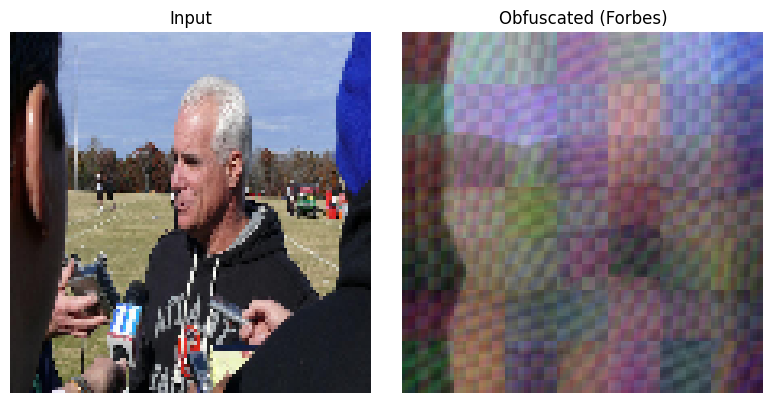

In [16]:
import cv2, os, torch
from torchvision.utils import save_image
import matplotlib.pyplot as plt

IMG_PATH = list(uploaded.keys())[0]

img = cv2.imread(IMG_PATH)
img = cv2.resize(img, (112, 112))  # AdaFace requires 112x112 input
img_torch = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1
img_torch = img_torch.to(device)

with torch.no_grad():
    output = optimizer_brs.optimize(img_torch)

out_path = os.path.join(OUTPUT_DIR, 'output.png')
save_image(output[:, [2, 1, 0]] / 2 + 0.5, out_path)
print(f'Saved to {out_path}')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input')
axes[0].axis('off')
out_bgr = cv2.imread(out_path)
axes[1].imshow(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('Obfuscated (Forbes)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 9. Evaluation on LFW  (`eval.py`)

Use `lfw/lfw.npy` and `lfw/lfw_list.npy` from.
Dataset: https://github.com/ZhaoJ9014/face.evoLVe

**NOTE:** The lfw.npy is in the .bin format. You have to write a script to conver to .npy format.

In [14]:
import numpy as np, os, torch
import torch.utils.data as data
from torch.utils.data import DataLoader

# set path containing lfw/
DATASET_ROOT = '/content/drive/MyDrive/acv_project_weights/'
BATCH_SIZE   = 16


class LFW(data.Dataset):
    def __init__(self, root):
        self.pairs  = np.load(os.path.join(root, 'lfw', 'lfw.npy'))
        self.issame = np.load(os.path.join(root, 'lfw', 'lfw_list.npy'))
    def __getitem__(self, i):
        s = self.pairs[i]
        return {'im1': (s[0] + 1) / 2, 'im2': (s[1] + 1) / 2, 'tf': self.issame[i] * 1}
    def __len__(self):
        return len(self.pairs)


def cal_accuracy(y_score, y_true):
    y_score, y_true = np.asarray(y_score), np.asarray(y_true)
    best_acc, best_th = 0, 0
    for th in y_score:
        acc = np.mean(((y_score >= th) == y_true).astype(int))
        if acc > best_acc:
            best_acc, best_th = acc, th
    return best_acc, best_th


def run_eval(dataset_root, batch_size):
    loader = DataLoader(LFW(dataset_root), num_workers=2, batch_size=batch_size, shuffle=False)
    labels, sims = [], []
    with torch.no_grad():
        for i, blob in enumerate(loader, 1):
            for k in ('im1', 'im2'):
                blob[k] = blob[k].to(device)
            b = blob['im1'].shape[0]
            opt = optimizer_brs.optimize(blob['im1'] * 2 - 1)
            feat, _ = model(torch.cat((opt, blob['im2'] * 2 - 1), dim=0))
            sim = torch.bmm(feat[:b].unsqueeze(1), feat[b:].unsqueeze(2)).squeeze(1).squeeze(1)
            sims.extend(sim.cpu())
            labels.extend(blob['tf'])
            print(f'===> [{i}/{len(loader)}]', end='\r')
    acc, th = cal_accuracy(sims, labels)
    print(f'\n== [Forbes] Accuracy: {acc:.6f}  Threshold: {th:.6f} ==')


run_eval(DATASET_ROOT, BATCH_SIZE)


===> [375/375]
== [Forbes] Accuracy: 0.978000  Threshold: 0.115921 ==
